## 1. Project Overview

This project evaluates machine learning models for estimating whether a patient with diabetes will be readmitted within 30 days of hospital discharge. It is an educational decision-support prototype and is not intended for clinical use.

## 2. Dataset and Clinical Context

The project uses the Diabetes 130-US Hospitals for Years 1999–2008 dataset, which contains 101,766 hospital encounters from 130 US hospitals. Each row represents one hospital encounter, and the same patient may appear multiple times, so data must be split at the patient level to prevent leakage.

## 3. Prediction Target

The original `readmitted` variable contains three outcomes:

- `<30`: the patient was readmitted within 30 days;
- `>30`: the patient was readmitted after more than 30 days;
- `NO`: no readmission was recorded.

For this project, the task is converted into binary classification:

- `1`: readmission within 30 days (`<30`);
- `0`: readmission after 30 days or no recorded readmission (`>30` or `NO`).

The original `readmitted` column is retained for validation but will not be used as an input feature because it directly defines the target.

In [70]:
import pandas as pd

# df uses '?' for missing data. Keeping Pandas' default NA parsing off also
# preserves 'None', which is a real category in the laboratory result columns.
df_raw = pd.read_csv(
    "../data/raw/diabetic_data.csv",
    keep_default_na=False,
    na_values=["?"],
    low_memory=False,

)

# Keep the original frame untouched so each cleaning decision remains traceable.
df = df_raw.copy()
df_raw.head(3).T

,0,1,2
encounter_id,2278392,149190,64410
patient_nbr,8222157,55629189,86047875
race,Caucasian,Caucasian,AfricanAmerican
gender,Female,Female,Female
age,[0-10),[10-20),[20-30)
weight,NaN,NaN,NaN
admission_type_id,6,1,1
discharge_disposition_id,25,1,1
admission_source_id,1,7,7
time_in_hospital,1,3,2


## 4. Data Quality and Cleaning

In [71]:
# These columns need a closer look before choosing between removal, imputation,
# or keeping a separate category for unavailable information.
for col in [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(15))


weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

max_glu_serum
max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

A1Cresult
A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

medical_specialty
medical_specialty
NaN                                49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                   

In [72]:
# Counts alone can be misleading, so keep the percentage beside them.
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing[missing["missing_count"] > 0].sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [73]:
# Missingness is too extensive in these columns to support a simple, defensible
# imputation strategy for the first baseline.
#weight has to too many missing values, and payer_code is not informative for other hospitals for example.
df = df.drop(columns=["weight", "payer_code"])

In [74]:
unknown_columns = [
    "medical_specialty",
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

# For these categorical fields, 'not recorded' may carry useful information.
# Preserve it explicitly instead of replacing it with the most common value.
df[unknown_columns] = df[unknown_columns].fillna("Unknown")
df[unknown_columns].head(5)

,medical_specialty,race,diag_1,diag_2,diag_3
0,Pediatrics-Endocrinology,Caucasian,250.83,Unknown,Unknown
1,Unknown,Caucasian,276,250.01,255
2,Unknown,AfricanAmerican,648,250,V27
3,Unknown,Caucasian,8,250.43,403
4,Unknown,Caucasian,197,157,250


In [75]:
for column in unknown_columns:
    unknown_count = (df[column] == "Unknown").sum()
    unknown_percent = unknown_count / len(df) * 100

    print(
        f"{column}: {unknown_count} "
        f"({unknown_percent:.2f}%)"
    )

medical_specialty: 49949 (49.08%)
race: 2273 (2.23%)
diag_1: 21 (0.02%)
diag_2: 358 (0.35%)
diag_3: 1423 (1.40%)


In [76]:
# check the remaining missing values
df.isna().sum().sort_values(ascending=False)

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

In [77]:
TARGET_COLUMN = "readmitted_30d"

df[TARGET_COLUMN] = (df["readmitted"] == "<30").astype("int8")

target_summary = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis("readmitted_30d")
    .to_frame("count")
)

target_summary["percent"] = (
    target_summary["count"] / len(df) * 100
).round(2)

target_summary

,count,percent
readmitted_30d,,
0,90409,88.84
1,11357,11.16


In [78]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate encounter IDs:", df["encounter_id"].duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique())

Duplicate rows: 0
Duplicate encounter IDs: 0
Unique patients: 71518


In [79]:
df["gender"] = df["gender"].replace("Unknown/Invalid", "Unknown")
df["gender"].value_counts(dropna=False)

gender
Female     54708
Male       47055
Unknown        3
Name: count, dtype: int64

In [80]:
unique_counts = df.nunique(dropna=False)

unique_counts[unique_counts == 1]

examide        1
citoglipton    1
dtype: int64

In [81]:
# these columns have only one unique value, so they cannot be used for prediction.
df = df.drop(columns=["examide", "citoglipton"])


In [82]:
df.shape

(101766, 47)

## 5. Leakage-Safe Data Split

The data is split by `patient_nbr`, so every encounter from the same patient stays in one subset. The 60/20/20 patient split keeps validation data available for model and threshold selection while leaving the test set untouched for final evaluation.

In [83]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
GROUP_COLUMN = "patient_nbr" # better if we change patient_nbr ,than we change only in one place

# First reserve 40% of patients for validation and test data.
train_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.40,
    random_state=RANDOM_STATE,
)
train_idx, holdout_idx = next(
    train_splitter.split(df, groups=df[GROUP_COLUMN])
)  

train_df = df.iloc[train_idx].copy()
holdout_df = df.iloc[holdout_idx].copy()

# Split the reserved patients equally into validation and test subsets.
holdout_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=RANDOM_STATE + 1,
)
validation_idx, test_idx = next(
    holdout_splitter.split(holdout_df, groups=holdout_df[GROUP_COLUMN])
)

validation_df = holdout_df.iloc[validation_idx].copy()
test_df = holdout_df.iloc[test_idx].copy()



In [84]:
train_patients = set(train_df[GROUP_COLUMN])
validation_patients = set(validation_df[GROUP_COLUMN])
test_patients = set(test_df[GROUP_COLUMN])

assert train_patients.isdisjoint(validation_patients)
assert train_patients.isdisjoint(test_patients)
assert validation_patients.isdisjoint(test_patients)
assert len(train_df) + len(validation_df) + len(test_df) == len(df)
assert set(df[TARGET_COLUMN].unique()) == {0, 1}


In [85]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "encounters": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "encounter_percent": [
        len(train_df) / len(df) * 100,
        len(validation_df) / len(df) * 100,
        len(test_df) / len(df) * 100,
    ],
    "patients": [
        train_df[GROUP_COLUMN].nunique(),
        validation_df[GROUP_COLUMN].nunique(),
        test_df[GROUP_COLUMN].nunique(),
    ],
    "positive_rate_percent": [
        train_df[TARGET_COLUMN].mean() * 100,
        validation_df[TARGET_COLUMN].mean() * 100,
        test_df[TARGET_COLUMN].mean() * 100,
    ],
}).set_index("split").round(2)


print(split_summary)



            encounters  encounter_percent  patients  positive_rate_percent
split                                                                     
train            61326              60.26     42910                  11.19
validation       20187              19.84     14304                  10.81
test             20253              19.90     14304                  11.42


## 6. Exploratory Data Analysis

These summaries use only training encounters. They describe the data and do not establish causal relationships.

In [86]:
train_class_counts = train_df[TARGET_COLUMN].value_counts().sort_index()
train_class_summary = pd.DataFrame({
    "encounters": train_class_counts,
    "percent": (train_class_counts / len(train_df) * 100).round(1),
})
train_class_summary.index = ["No readmission within 30 days", "Readmitted within 30 days"]
train_class_summary

,encounters,percent
No readmission within 30 days,54464,88.8
Readmitted within 30 days,6862,11.2


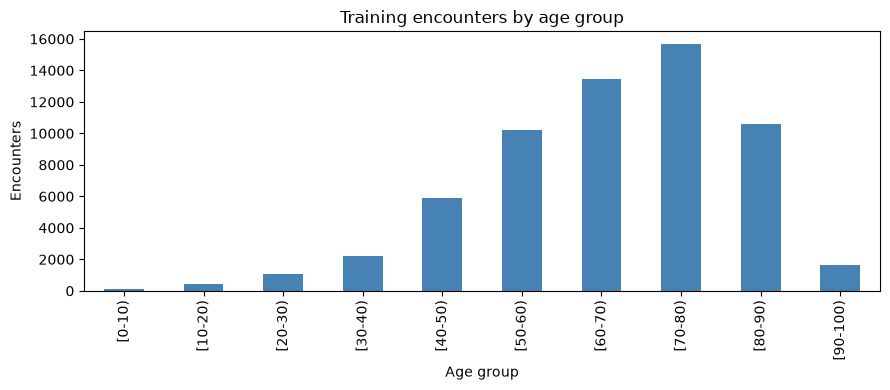

In [87]:
import matplotlib.pyplot as plt

age_counts = train_df["age"].value_counts().sort_index()
age_counts.plot.bar(figsize=(9, 4), color="steelblue")
plt.title("Training encounters by age group")
plt.xlabel("Age group")
plt.ylabel("Encounters")
plt.tight_layout()
plt.show()

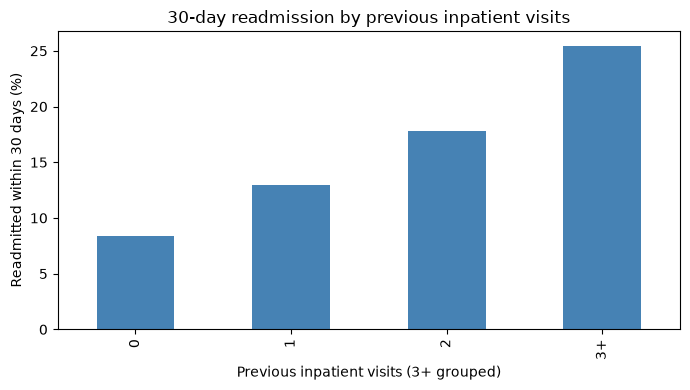

In [88]:
# Group three or more prior admissions together for a readable chart.
prior_inpatient_visits = train_df["number_inpatient"].clip(upper=3)
readmission_rate = (
    train_df.groupby(prior_inpatient_visits)[TARGET_COLUMN]
    .mean()
    .mul(100)
    .rename(index={0: "0", 1: "1", 2: "2", 3: "3+"})
)
readmission_rate.plot.bar(figsize=(7, 4), color="steelblue")
plt.title("30-day readmission by previous inpatient visits")
plt.xlabel("Previous inpatient visits (3+ grouped)")
plt.ylabel("Readmitted within 30 days (%)")
plt.tight_layout()
plt.show()

Only 11.2% of training encounters ended in readmission within 30 days, so accuracy alone will not describe model performance well. The observed readmission rate rises from 8.4% with no previous inpatient visits to 25.5% with three or more; this is an association, not evidence of causation.

### Feature and Target Separation

In [89]:
EXCLUDED_FEATURES = [
    "encounter_id",
    "patient_nbr",
    "race",
    "readmitted",
    "readmitted_30d",
]

# Keep race aligned for later subgroup analysis.
X_train = train_df.drop(columns=EXCLUDED_FEATURES).copy()
y_train = train_df[TARGET_COLUMN].copy()
race_train = train_df["race"].copy()

X_validation = validation_df.drop(columns=EXCLUDED_FEATURES).copy()
y_validation = validation_df[TARGET_COLUMN].copy()
race_validation = validation_df["race"].copy()

X_test = test_df.drop(columns=EXCLUDED_FEATURES).copy()
y_test = test_df[TARGET_COLUMN].copy()
race_test = test_df["race"].copy()


#check are there any excluded features in the X_train, X_validation, and X_test datasets and check if the columns are equal across the datasets
assert GROUP_COLUMN in EXCLUDED_FEATURES and TARGET_COLUMN in EXCLUDED_FEATURES
assert X_train.columns.equals(X_validation.columns)
assert X_train.columns.equals(X_test.columns)

for X, y, race, split in [
    (X_train, y_train, race_train, train_df),
    (X_validation, y_validation, race_validation, validation_df),
    (X_test, y_test, race_test, test_df),
]:
    assert not set(EXCLUDED_FEATURES).intersection(X.columns)
    assert len(X) == len(y) == len(race) == len(split)
    assert X.index.equals(y.index) and X.index.equals(race.index) #check if X , y and race have the same index f.e(x=1, y=1, race=1)
    assert race.equals(split["race"])
    assert y.isin([0, 1]).all() #check if y contains only 0 and 1 values,without NaN values
    assert not X.isna().any().any()

for name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_validation, y_validation),
    ("test", X_test, y_test),
]:
    print(f"{name}: X={X.shape}, y={y.shape}")
print(f"Feature columns: {X_train.shape[1]}")
print(f"Excluded features: {EXCLUDED_FEATURES}")
print("All assertions passed.")

train: X=(61326, 42), y=(61326,)
validation: X=(20187, 42), y=(20187,)
test: X=(20253, 42), y=(20253,)
Feature columns: 42
Excluded features: ['encounter_id', 'patient_nbr', 'race', 'readmitted', 'readmitted_30d']
All assertions passed.


### Feature Type Classification

In [90]:
EXPLICIT_CATEGORICAL_COLUMNS = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
]
# String columns are categorical; the three numeric IDs are categorical too.
text_columns = X_train.select_dtypes(include=["object", "string", "category"]).columns
categorical_columns = [
    column for column in X_train.columns
    if column in text_columns or column in EXPLICIT_CATEGORICAL_COLUMNS
]
numerical_columns = [
    column for column in X_train.columns if column not in categorical_columns
]

assert set(categorical_columns).isdisjoint(numerical_columns)
assert set(categorical_columns + numerical_columns) == set(X_train.columns)
assert not set(EXCLUDED_FEATURES).intersection(categorical_columns + numerical_columns)
assert set(EXPLICIT_CATEGORICAL_COLUMNS + ["diag_1", "diag_2", "diag_3"]).issubset(categorical_columns)
assert all(pd.api.types.is_numeric_dtype(X_train[column]) for column in numerical_columns)
assert X_train.columns.equals(X_validation.columns) and X_train.columns.equals(X_test.columns)
for X, split in [(X_train, train_df), (X_validation, validation_df), (X_test, test_df)]:
    assert X.equals(split.drop(columns=EXCLUDED_FEATURES))

feature_inspection = pd.DataFrame({
    "feature": X_train.columns,
    "pandas_dtype": X_train.dtypes.astype(str).values,
    "assigned_type": ["categorical" if column in categorical_columns else "numerical" for column in X_train.columns],
    "train_unique_values": X_train.nunique(dropna=False).values,
})
print(feature_inspection.to_string(index=False))
print(f"Features: {X_train.shape[1]} (numerical: {len(numerical_columns)}, categorical: {len(categorical_columns)})")
print(f"Numerical: {numerical_columns}")
print(f"Categorical: {categorical_columns}")
print("All assertions passed.")

                 feature pandas_dtype assigned_type  train_unique_values
                  gender          str   categorical                    3
                     age          str   categorical                   10
       admission_type_id        int64   categorical                    8
discharge_disposition_id        int64   categorical                   25
     admission_source_id        int64   categorical                   17
        time_in_hospital        int64     numerical                   14
       medical_specialty          str   categorical                   69
      num_lab_procedures        int64     numerical                  115
          num_procedures        int64     numerical                    7
         num_medications        int64     numerical                   72
       number_outpatient        int64     numerical                   34
        number_emergency        int64     numerical                   31
        number_inpatient        int64     numerical

### Leakage-Safe Preprocessing

Numerical columns are standardized and categorical columns are one-hot encoded. Preprocessing is fitted only on the training data, then applied to validation data.

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore") #doesnt raise an error if value isnt seen in training data

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numerical_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ],
    remainder="drop",
)

# Learn scaling values and categories from training data only.
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
processed_feature_names = preprocessor.get_feature_names_out()

assert X_train_processed.shape[0] == X_train.shape[0]
assert X_validation_processed.shape[0] == X_validation.shape[0]
assert X_train_processed.shape[1] == X_validation_processed.shape[1]
assert len(processed_feature_names) == X_train_processed.shape[1]

print(f"Train: raw {X_train.shape}, processed {X_train_processed.shape}")
print(f"Validation: raw {X_validation.shape}, processed {X_validation_processed.shape}")
print(f"Processed features: {len(processed_feature_names)}")
print(f"First 20 feature names: {list(processed_feature_names[:20])}")
print("Preprocessing checks passed.")

Train: raw (61326, 42), processed (61326, 2297)
Validation: raw (20187, 42), processed (20187, 2297)
Processed features: 2297
First 20 feature names: ['numeric__time_in_hospital', 'numeric__num_lab_procedures', 'numeric__num_procedures', 'numeric__num_medications', 'numeric__number_outpatient', 'numeric__number_emergency', 'numeric__number_inpatient', 'numeric__number_diagnoses', 'categorical__gender_Female', 'categorical__gender_Male', 'categorical__gender_Unknown', 'categorical__age_[0-10)', 'categorical__age_[10-20)', 'categorical__age_[20-30)', 'categorical__age_[30-40)', 'categorical__age_[40-50)', 'categorical__age_[50-60)', 'categorical__age_[60-70)', 'categorical__age_[70-80)', 'categorical__age_[80-90)']
Preprocessing checks passed.


## 8. Baseline Model

Using dummy model to see real progress we made later

In [94]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DummyClassifier(strategy="prior")),
])
baseline_pipeline.fit(X_train, y_train)

baseline_predictions = baseline_pipeline.predict(X_validation)
baseline_probabilities = baseline_pipeline.predict_proba(X_validation)[:, 1]

# Precision is set to zero when the baseline predicts no readmissions.
baseline_metrics = pd.Series({
    "accuracy": accuracy_score(y_validation, baseline_predictions),
    "precision": precision_score(y_validation, baseline_predictions, zero_division=0),
    "recall": recall_score(y_validation, baseline_predictions),
    "f1": f1_score(y_validation, baseline_predictions),
    "roc_auc": roc_auc_score(y_validation, baseline_probabilities),
    "pr_auc": average_precision_score(y_validation, baseline_probabilities),
})
print(f"Predicted readmissions: {baseline_predictions.sum()} of {len(y_validation)}")
print(baseline_metrics.round(3))

Predicted readmissions: 0 of 20187
accuracy     0.892
precision    0.000
recall       0.000
f1           0.000
roc_auc      0.500
pr_auc       0.108
dtype: float64


This result is expected: roughly 90% of validation encounters are negative and only 10% are positive, so the dummy model predicts the negative class every time. Its high accuracy is misleading because it misses every readmission, giving recall and F1 scores of zero.

## 9. Model Comparison

Logistic regression learns from the training features. We compare its validation results with the dummy baseline using the default 0.5 decision threshold; the test set remains untouched.

In [95]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_validation)
logistic_probabilities = logistic_pipeline.predict_proba(X_validation)[:, 1]

logistic_metrics = pd.Series({
    "accuracy": accuracy_score(y_validation, logistic_predictions), #for us not as impportant as some of the other metrics, cause we have imbalanced dataset
    "precision": precision_score(y_validation, logistic_predictions, zero_division=0),
    "recall": recall_score(y_validation, logistic_predictions),
    "f1": f1_score(y_validation, logistic_predictions),
    "roc_auc": roc_auc_score(y_validation, logistic_probabilities),
    "pr_auc": average_precision_score(y_validation, logistic_probabilities), #most important for us, cause we search for the "needle in the haystack".
})
model_comparison = pd.DataFrame({
    "Dummy baseline": baseline_metrics,
    "Logistic regression": logistic_metrics,
}).T
print(f"Predicted readmissions: {logistic_predictions.sum()} of {len(y_validation)}")
print(model_comparison.round(3))

Predicted readmissions: 79 of 20187
                     accuracy  precision  recall     f1  roc_auc  pr_auc
Dummy baseline          0.892      0.000   0.000  0.000    0.500   0.108
Logistic regression     0.892      0.494   0.018  0.034    0.664   0.209


### Class-Weighted Logistic Regression

`class_weight="balanced"` gives the rarer readmission class more weight during training. We compare it on the same validation set using the same 0.5 threshold.

In [96]:
balanced_logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
balanced_logistic_pipeline.fit(X_train, y_train)

balanced_predictions = balanced_logistic_pipeline.predict(X_validation)
balanced_probabilities = balanced_logistic_pipeline.predict_proba(X_validation)[:, 1]

balanced_metrics = pd.Series({
    "accuracy": accuracy_score(y_validation, balanced_predictions),
    "precision": precision_score(y_validation, balanced_predictions, zero_division=0),
    "recall": recall_score(y_validation, balanced_predictions),
    "f1": f1_score(y_validation, balanced_predictions),
    "roc_auc": roc_auc_score(y_validation, balanced_probabilities),
    "pr_auc": average_precision_score(y_validation, balanced_probabilities),
})
model_comparison.loc["Logistic regression (balanced)"] = balanced_metrics
print(f"Predicted readmissions: {balanced_predictions.sum()} of {len(y_validation)}")
print(model_comparison.round(3).to_string())

Predicted readmissions: 7089 of 20187
                                accuracy  precision  recall     f1  roc_auc  pr_auc
Dummy baseline                     0.892      0.000   0.000  0.000    0.500   0.108
Logistic regression                0.892      0.494   0.018  0.034    0.664   0.209
Logistic regression (balanced)     0.662      0.172   0.559  0.263    0.665   0.211


At the default 0.5 threshold, standard Logistic Regression has high precision (0.494) but very low recall (0.018), so it misses almost all readmissions. With `class_weight="balanced"`, recall rises to 0.559 while precision falls to 0.172: it catches more readmissions but produces more false alarms. ROC-AUC and PR-AUC change very little, so the main difference here is which cases each model labels positive at this threshold. These are validation results; the test set has not been used.

### Random Forest

Random Forest provides a nonlinear comparison model. Class weighting gives the minority 30-day readmission class more influence during training.

In [97]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
random_forest_pipeline.fit(X_train, y_train)

random_forest_probabilities = random_forest_pipeline.predict_proba(X_validation)[:, 1]
random_forest_predictions = random_forest_pipeline.predict(X_validation)

random_forest_metrics = pd.Series({
    "accuracy": accuracy_score(y_validation, random_forest_predictions),
    "precision": precision_score(y_validation, random_forest_predictions, zero_division=0),
    "recall": recall_score(y_validation, random_forest_predictions, zero_division=0),
    "f1": f1_score(y_validation, random_forest_predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_validation, random_forest_probabilities),
    "pr_auc": average_precision_score(y_validation, random_forest_probabilities),
})
model_comparison.loc["Random Forest (balanced)"] = random_forest_metrics
print(f"Predicted validation readmissions: {random_forest_predictions.sum()}")
print(model_comparison.round(3).to_string())

Predicted validation readmissions: 7697
                                accuracy  precision  recall     f1  roc_auc  pr_auc
Dummy baseline                     0.892      0.000   0.000  0.000    0.500   0.108
Logistic regression                0.892      0.494   0.018  0.034    0.664   0.209
Logistic regression (balanced)     0.662      0.172   0.559  0.263    0.665   0.211
Random Forest (balanced)           0.644      0.174   0.615  0.272    0.681   0.203


## 10. Decision Threshold Selection

We now evaluate different decision thresholds on the validation set. The threshold is selected using validation data only; the test set remains untouched.

### Standard Logistic Regression

In [98]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for threshold in thresholds:
    threshold_predictions = (logistic_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, threshold_predictions, zero_division=0),
        "recall": recall_score(y_validation, threshold_predictions, zero_division=0),
        "f1": f1_score(y_validation, threshold_predictions, zero_division=0),
        "predicted_positive": int(threshold_predictions.sum()),
    })

threshold_table = pd.DataFrame(threshold_results)
display(threshold_table)

,threshold,precision,recall,f1,predicted_positive
0,0.10,0.159832,0.644526,0.256144,8803
1,0.15,0.203256,0.377462,0.264230,4054
2,0.20,0.258366,0.240495,0.249110,2032
3,0.25,0.309397,0.159872,0.210812,1128
4,0.30,0.355243,0.103985,0.160879,639
5,0.35,0.382812,0.067339,0.114531,384
6,0.40,0.377778,0.038937,0.070598,225
7,0.45,0.430769,0.025653,0.048422,130
8,0.50,0.493671,0.017865,0.034483,79


In [99]:
fine_thresholds = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15,
                   0.16, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25] #checking the thresholds from a step of 0.01 to find the best threshold for our model
fine_threshold_results = []

for threshold in fine_thresholds:
    predictions = (logistic_probabilities >= threshold).astype(int)

    fine_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "predicted_positive": int(predictions.sum()),
    })

fine_threshold_table = pd.DataFrame(fine_threshold_results)
display(fine_threshold_table)

,threshold,precision,recall,f1,predicted_positive
0,0.10,0.159832,0.644526,0.256144,8803
1,0.11,0.168125,0.580852,0.260771,7542
2,0.12,0.178095,0.525882,0.266079,6446
3,0.13,0.185694,0.470912,0.266356,5536
4,0.14,0.194978,0.423271,0.266975,4739
5,0.15,0.203256,0.377462,0.264230,4054
6,0.16,0.217429,0.346312,0.267138,3477
7,0.17,0.223069,0.308291,0.258846,3017
8,0.18,0.231523,0.281264,0.253981,2652
9,0.19,0.242938,0.256070,0.249331,2301


The decision threshold was selected using the validation set only. Thresholds around 0.15–0.17 produced similar F1 scores. A threshold of 0.16 was selected as a balanced operating point between precision and recall, while avoiding the extremely low recall observed at the default threshold of 0.50.


Best threshold candidate is 0.16 for logistic regression


### Balanced Logistic Regression

In [100]:
candidate_thresholds = [
    0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95
]

balanced_threshold_results = []

for threshold in candidate_thresholds:
    balanced_threshold_predictions = (balanced_probabilities >= threshold).astype(int)

    balanced_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, balanced_threshold_predictions, zero_division=0),
        "recall": recall_score(y_validation, balanced_threshold_predictions, zero_division=0),
        "f1": f1_score(y_validation, balanced_threshold_predictions, zero_division=0),
        "predicted_positive": int(balanced_threshold_predictions.sum()),
    })

balanced_threshold_table = pd.DataFrame(balanced_threshold_results)
display(balanced_threshold_table.round(3))

,threshold,precision,recall,f1,predicted_positive
0,0.05,0.110,0.998,0.198,19785
1,0.10,0.111,0.992,0.200,19502
2,0.15,0.113,0.985,0.202,19081
3,0.20,0.115,0.971,0.206,18434
4,0.25,0.119,0.943,0.211,17336
5,0.30,0.124,0.898,0.218,15786
6,0.35,0.133,0.838,0.229,13766
7,0.40,0.143,0.756,0.240,11544
8,0.45,0.158,0.669,0.256,9251
9,0.50,0.172,0.559,0.263,7089


In [101]:
narrow_thresholds = [0.55, 0.56, 0.57, 0.58, 0.59, 0.60, 0.61, 0.62, 0.63, 0.64, 0.65]
balanced_narrow_results = []

for threshold in narrow_thresholds:
    predictions = (balanced_probabilities >= threshold).astype(int)

    balanced_narrow_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "predicted_positive": int(predictions.sum()),
    })

balanced_narrow_table = pd.DataFrame(balanced_narrow_results)
display(balanced_narrow_table.round(3))

,threshold,precision,recall,f1,predicted_positive
0,0.55,0.192,0.461,0.271,5243
1,0.56,0.196,0.441,0.271,4907
2,0.57,0.199,0.419,0.270,4589
3,0.58,0.204,0.400,0.270,4273
4,0.59,0.207,0.377,0.267,3978
5,0.60,0.211,0.358,0.266,3701
6,0.61,0.217,0.339,0.265,3411
7,0.62,0.223,0.323,0.264,3171
8,0.63,0.225,0.306,0.259,2961
9,0.64,0.231,0.292,0.258,2756


The decision threshold was selected using the validation set only. Thresholds between 0.55 and 0.58 produced very similar F1 scores. A threshold of 0.56 was selected as a balanced operating point, preserving a recall of 0.441 while slightly improving precision compared with 0.55.

Best candidate is 0.56 from Balanced Logistic Regression



### Balanced Random Forest

In [102]:
forest_thresholds = [
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75,
    0.80, 0.85, 0.90, 0.95, 1.00,
]

forest_threshold_results = []

for threshold in forest_thresholds:
    predictions = (random_forest_probabilities >= threshold).astype(int)

    forest_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "predicted_positive": int(predictions.sum()),
    })

forest_threshold_table = pd.DataFrame(forest_threshold_results)
display(forest_threshold_table.round(3))

,threshold,precision,recall,f1,predicted_positive
0,0.05,0.108,1.000,0.195,20187
1,0.10,0.108,1.000,0.195,20187
2,0.15,0.108,1.000,0.195,20187
3,0.20,0.108,1.000,0.195,20187
4,0.25,0.108,1.000,0.195,20187
5,0.30,0.108,1.000,0.195,20187
6,0.35,0.109,1.000,0.197,20019
7,0.40,0.114,0.980,0.205,18723
8,0.45,0.134,0.888,0.233,14465
9,0.50,0.174,0.615,0.272,7697


In [103]:
forest_fine_results = []

for threshold in [0.46, 0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54]:
    predictions = (random_forest_probabilities >= threshold).astype(int)

    forest_fine_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "f1": f1_score(y_validation, predictions, zero_division=0),
        "predicted_positive": int(predictions.sum()),
    })

forest_fine_table = pd.DataFrame(forest_fine_results)
display(forest_fine_table.round(3))

,threshold,precision,recall,f1,predicted_positive
0,0.46,0.141,0.852,0.242,13186
1,0.47,0.148,0.805,0.251,11837
2,0.48,0.156,0.743,0.258,10392
3,0.49,0.165,0.682,0.266,8997
4,0.50,0.174,0.615,0.272,7697
5,0.51,0.184,0.541,0.275,6415
6,0.52,0.195,0.455,0.273,5101
7,0.53,0.209,0.373,0.268,3905
8,0.54,0.226,0.295,0.256,2848


Among the tested Random Forest thresholds from 0.46 to 0.54, **0.51 achieved the highest validation F1 score (0.275)**. At this threshold, precision was 0.184 and recall was 0.541. Compared with 0.50, F1 improved slightly, while recall decreased; the test set was not used.

In [104]:
standard_result = fine_threshold_table.loc[
    fine_threshold_table["threshold"] == 0.16
].iloc[0]

balanced_result = balanced_narrow_table.loc[
    balanced_narrow_table["threshold"] == 0.56
].iloc[0]

forest_result = forest_fine_table.loc[
    forest_fine_table["threshold"] == 0.51
].iloc[0]

winner_comparison = pd.DataFrame(
    [standard_result, balanced_result, forest_result],
    index=[
        "Standard Logistic Regression",
        "Balanced Logistic Regression",
        "Balanced Random Forest",
    ],
)

winner_comparison["predicted_positive"] = winner_comparison["predicted_positive"].astype(int)
display(winner_comparison.round(3))

winner = winner_comparison["f1"].idxmax()
print(f"Highest validation F1: {winner} at threshold {winner_comparison.loc[winner, 'threshold']:.2f}")

,threshold,precision,recall,f1,predicted_positive
Standard Logistic Regression,0.16,0.217,0.346,0.267,3477
Balanced Logistic Regression,0.56,0.196,0.441,0.271,4907
Balanced Random Forest,0.51,0.184,0.541,0.275,6415


Highest validation F1: Balanced Random Forest at threshold 0.51


## 11. Final Test Evaluation

The final model and decision threshold were selected using only the training and validation sets. The test set is now used once for the final unbiased evaluation.

In [105]:
from sklearn.metrics import confusion_matrix

test_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.51).astype(int)

test_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, test_predictions),
    "precision": precision_score(y_test, test_predictions, zero_division=0),
    "recall": recall_score(y_test, test_predictions, zero_division=0),
    "f1": f1_score(y_test, test_predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
})

test_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, test_predictions),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

print("Final test metrics (threshold 0.51):")
print(test_metrics.round(3).to_string())
print(f"Predicted positive cases: {test_predictions.sum()}")
display(test_confusion_matrix)

Final test metrics (threshold 0.51):
accuracy     0.682
precision    0.182
recall       0.510
f1           0.268
roc_auc      0.658
pr_auc       0.199
Predicted positive cases: 6481


,Predicted 0,Predicted 1
Actual 0,12639,5302
Actual 1,1133,1179


## 12. Model Interpretation

### Feature Importance

Random Forest feature importance shows which transformed features contributed most to the model's training splits. It does not show causality or whether a feature increases or decreases readmission risk. Since categorical variables were one-hot encoded, individual categories appear as separate features.

,feature,importance
0,numeric__number_inpatient,0.146906
1,categorical__discharge_disposition_id_1,0.055248
2,categorical__discharge_disposition_id_11,0.051298
3,numeric__number_emergency,0.047586
4,categorical__discharge_disposition_id_22,0.037151
5,numeric__number_diagnoses,0.027829
6,numeric__time_in_hospital,0.026789
7,numeric__num_medications,0.026382
8,categorical__discharge_disposition_id_3,0.024647
9,numeric__num_lab_procedures,0.018053


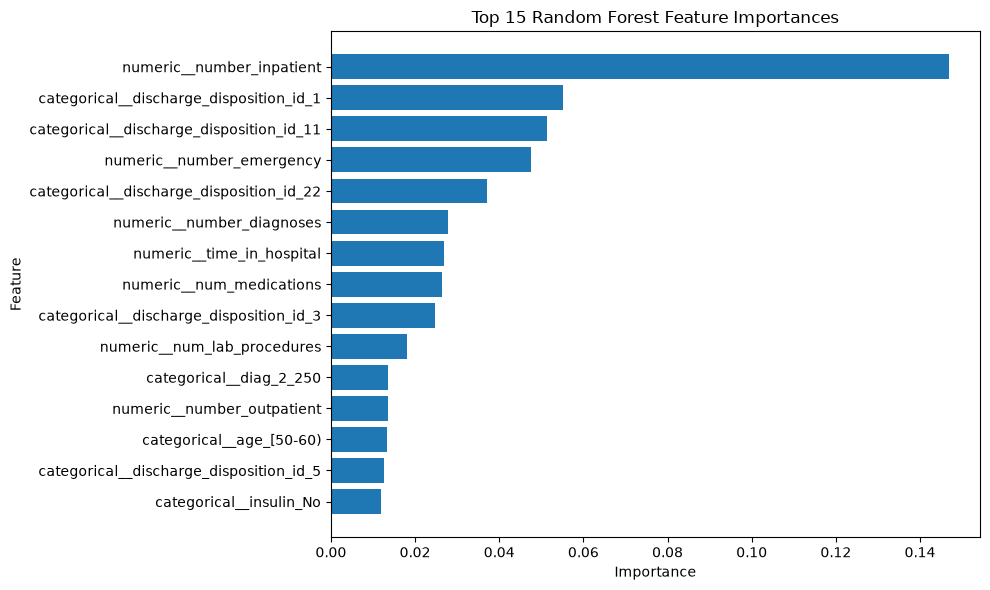

In [106]:
fitted_preprocessor = random_forest_pipeline.named_steps["preprocessing"]
feature_names = fitted_preprocessor.get_feature_names_out()

fitted_forest = random_forest_pipeline.named_steps["classifier"]

feature_importance_table = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_forest.feature_importances_,
})

feature_importance_table = feature_importance_table.sort_values(
    "importance", ascending=False
)

top_15_features = feature_importance_table.head(15).reset_index(drop=True)
display(top_15_features)

plt.figure(figsize=(10, 6))
plt.barh(top_15_features["feature"], top_15_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Previous inpatient visits (`number_inpatient`) had the highest individual feature importance (0.147). Previous emergency visits and several discharge-disposition categories also ranked highly, suggesting that prior healthcare utilization and discharge information contributed strongly to the Random Forest's decisions.
Feature importance does not establish causality or indicate whether a feature increases or decreases readmission risk. In addition, one-hot encoded categories are represented separately, and impurity-based Random Forest importance can be biased toward features with more possible split points.


### Subgroup Analysis by Race

Race was excluded from the model features and retained only for subgroup evaluation. We compare the final test predictions across race groups as a descriptive fairness check, not as proof of fairness or bias. Results for small groups may be unstable.

,race,n,positive_rate,precision,recall,f1
2,Caucasian,15099,0.115,0.182,0.518,0.269
0,AfricanAmerican,3874,0.118,0.190,0.505,0.277
5,Unknown,447,0.092,0.121,0.341,0.178
3,Hispanic,382,0.084,0.170,0.531,0.258
4,Other,312,0.103,0.148,0.375,0.212
1,Asian,139,0.108,0.188,0.400,0.255


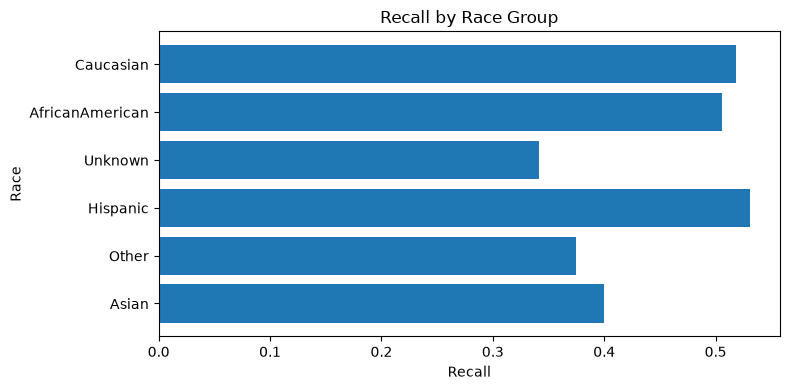

In [107]:
assert race_test.index.equals(y_test.index)
assert len(test_predictions) == len(y_test)

subgroup_df = pd.DataFrame({
    "race": race_test,
    "actual": y_test,
    "predicted": test_predictions,
})

subgroup_results = []

for race, group in subgroup_df.groupby("race", dropna=False):
    subgroup_results.append({
        "race": race,
        "n": len(group),
        "positive_rate": group["actual"].mean(),
        "precision": precision_score(group["actual"], group["predicted"], zero_division=0),
        "recall": recall_score(group["actual"], group["predicted"], zero_division=0),
        "f1": f1_score(group["actual"], group["predicted"], zero_division=0),
    })

subgroup_table = pd.DataFrame(subgroup_results).sort_values("n", ascending=False)
display(subgroup_table.round(3))

plt.figure(figsize=(8, 4))
plt.barh(subgroup_table["race"], subgroup_table["recall"])
plt.gca().invert_yaxis()
plt.title("Recall by Race Group")
plt.xlabel("Recall")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

## Subgroup Analysis by Race — Interpretation

Model performance was broadly similar for the two largest race groups, which also contain the vast majority of test encounters.

For **Caucasian** patients (`n = 15,099`), the model achieved a recall of **0.518**, precision of **0.182**, and F1 score of **0.269**. For **African American** patients (`n = 3,874`), performance was very similar, with recall **0.505**, precision **0.190**, and F1 score **0.277**.

This suggests that, within the two largest groups in the test set, the model showed comparable predictive behavior.

The smaller subgroups showed more variation. Recall ranged from **0.341** for patients with unknown race to **0.531** for Hispanic patients. However, these groups contained far fewer encounters, so their performance estimates are less stable and should be interpreted cautiously.

The positive readmission rate was also relatively similar across most groups, generally around 8–12%, although the smaller sample sizes again limit strong conclusions.

Overall, the subgroup analysis does not show a large performance difference between the two dominant race groups, but it is not sufficient to establish algorithmic fairness. More rigorous fairness assessment would require larger subgroup samples, confidence intervals, additional fairness metrics, and external validation.


## 13. Error Analysis

We use the final test predictions to see where the model succeeds and fails:

- **TP:** actual readmission, predicted readmission
- **FP:** no actual readmission, predicted readmission
- **FN:** actual readmission, predicted no readmission
- **TN:** no actual readmission, predicted no readmission

This analysis is descriptive and does not change the locked model.

In [108]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = test_predictions

error_df["prediction_group"] = ""
error_df.loc[(error_df["actual"] == 1) & (error_df["predicted"] == 1), "prediction_group"] = "TP"
error_df.loc[(error_df["actual"] == 0) & (error_df["predicted"] == 1), "prediction_group"] = "FP"
error_df.loc[(error_df["actual"] == 1) & (error_df["predicted"] == 0), "prediction_group"] = "FN"
error_df.loc[(error_df["actual"] == 0) & (error_df["predicted"] == 0), "prediction_group"] = "TN"

group_order = ["TP", "FP", "FN", "TN"]
group_counts = error_df["prediction_group"].value_counts().reindex(group_order, fill_value=0)
display(group_counts.to_frame("count"))

numeric_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
]

group_means = error_df.groupby("prediction_group")[numeric_features].mean()
display(group_means.reindex(group_order).round(2))

group_medians = error_df.groupby("prediction_group")[numeric_features].median()
display(group_medians.reindex(group_order).round(2))

,count
prediction_group,
TP,1179
FP,5302
FN,1133
TN,12639


,number_inpatient,number_emergency,number_outpatient,time_in_hospital,num_medications,number_diagnoses
prediction_group,,,,,,
TP,1.93,0.54,0.57,5.44,18.81,8.11
FP,1.29,0.42,0.62,5.70,18.61,8.27
FN,0.41,0.10,0.26,3.96,14.83,7.24
TN,0.24,0.08,0.26,3.79,14.74,7.05


,number_inpatient,number_emergency,number_outpatient,time_in_hospital,num_medications,number_diagnoses
prediction_group,,,,,,
TP,1.0,0.0,0.0,5.0,17.0,9.0
FP,1.0,0.0,0.0,5.0,18.0,9.0
FN,0.0,0.0,0.0,3.0,13.0,8.0
TN,0.0,0.0,0.0,3.0,13.0,8.0


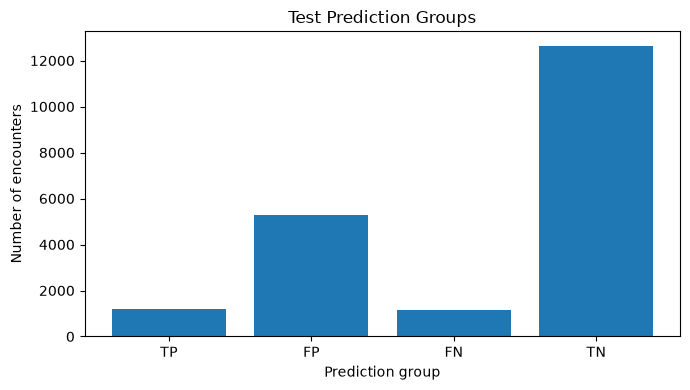

In [109]:
plt.figure(figsize=(7, 4))
plt.bar(group_counts.index, group_counts.values)
plt.title("Test Prediction Groups")
plt.xlabel("Prediction group")
plt.ylabel("Number of encounters")
plt.tight_layout()
plt.show()



For each patient encounter, we compare what actually happened with what the model predicted.

The first chart shows the four possible prediction outcomes:

True Positives (TP = 1,179): the model predicted a 30-day readmission and the patient was actually readmitted.
False Positives (FP = 5,302): the model predicted a readmission, but the patient was not readmitted.
False Negatives (FN = 1,133): the model predicted no readmission, but the patient was actually readmitted.
True Negatives (TN = 12,639): the model predicted no readmission and the patient was not readmitted.

The model therefore identified 1,179 actual readmissions, but it also produced a substantial number of false-positive alerts.

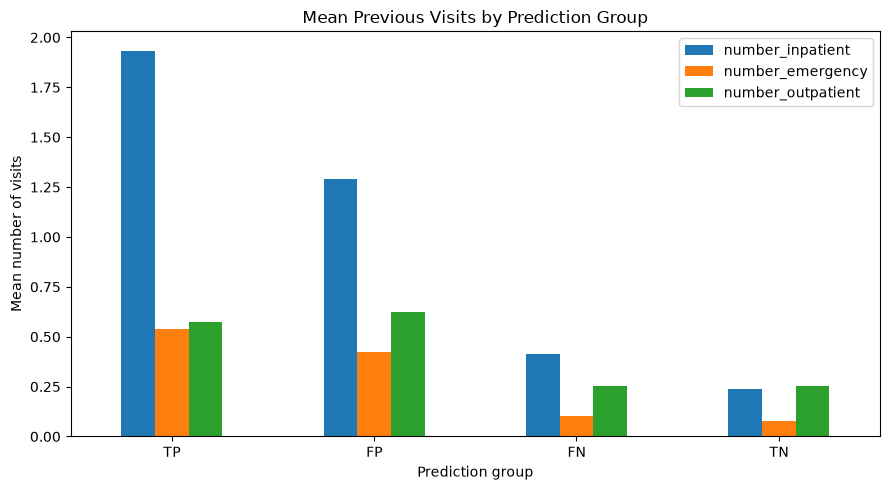

In [110]:
visit_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
]

group_means.loc[group_order, visit_features].plot.bar(figsize=(9, 5))
plt.title("Mean Previous Visits by Prediction Group")
plt.xlabel("Prediction group")
plt.ylabel("Mean number of visits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The second chart compares previous healthcare utilization across these four groups. In particular, patients in the true-positive group had, on average, 1.93 previous inpatient admissions, while patients in the false-negative group had only 0.41.

This suggests that the model is better at identifying readmission risk when a patient already has a stronger history of previous hospital use. In contrast, readmitted patients with fewer previous inpatient visits are more likely to be missed by the model.

This pattern is descriptive and does not imply causation. Previous hospital utilization may be associated with readmission risk, but these results do not show that previous visits themselves cause future readmission.

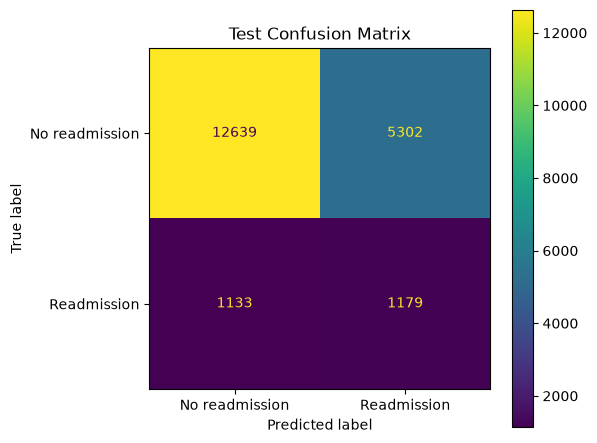

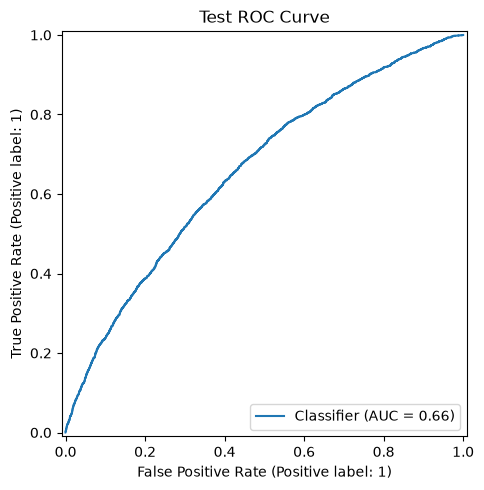

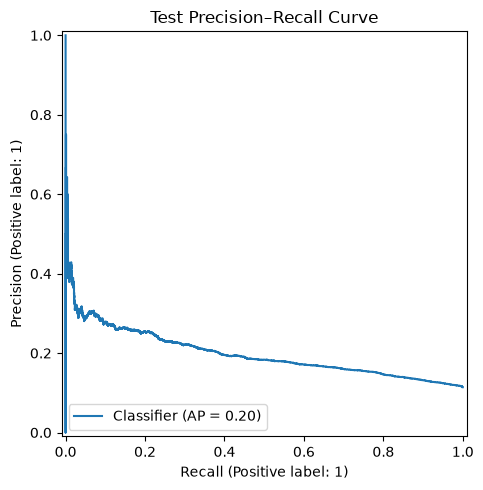

In [111]:
from pathlib import Path
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# The notebook runs from notebooks/, so ../reports points to the project folder.
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix.to_numpy(),
    display_labels=["No readmission", "Readmission"],
).plot(ax=ax)
ax.set_title("Test Confusion Matrix")
fig.tight_layout()
fig.savefig(figures_dir / "confusion_matrix.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=ax)
ax.set_title("Test ROC Curve")
fig.tight_layout()
fig.savefig(figures_dir / "roc_curve.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=ax)
ax.set_title("Test Precision–Recall Curve")
fig.tight_layout()
fig.savefig(figures_dir / "precision_recall_curve.png", dpi=150)
plt.show()



### Test Figure Summary

**Confusion matrix.** At the locked threshold of 0.51, the model correctly identified 1,179 readmissions and 12,639 non-readmissions. It missed 1,133 readmissions and produced 5,302 false-positive alerts. This corresponds to 51.0% recall and 18.2% precision.

**ROC curve.** The ROC-AUC of 0.658 shows modest ability to rank encounters that resulted in readmission above those that did not.

**Precision–recall curve.** The PR-AUC of 0.199 is above the test set's positive rate of about 0.114, but precision remains limited. The curve shows how precision and recall trade off across thresholds; it was not used to change the locked threshold.

## 14. Conclusions and Limitations



### 14.1 Conclusions

This project developed an explainable machine learning prototype for predicting 30-day hospital readmission among patients with diabetes.

#### 14.1.1 Patient-Level Split and Leakage Prevention

A patient-level train/validation/test split was used to prevent encounters from the same patient from appearing in multiple datasets. Preprocessing was fitted only on the training data, while the validation set was used for model comparison and decision-threshold selection. The test set remained untouched until the final evaluation.

#### 14.1.2 Model Selection

Three main modelling approaches were compared: Logistic Regression, class-balanced Logistic Regression, and a class-balanced Random Forest. The Random Forest was selected as the final model because it provided the strongest overall validation trade-off, with better recall, F1 score, and ROC-AUC than the logistic models.

#### 14.1.3 Final Test Performance

A decision threshold of **0.51** was selected using the validation set. On the independent test set, the final model achieved:

* **Precision:** 0.182
* **Recall:** 0.510
* **F1 score:** 0.268
* **ROC-AUC:** 0.658
* **PR-AUC:** 0.199

The model identified **1,179 of 2,312 actual 30-day readmissions**, corresponding to a recall of approximately 51%. However, it also generated **5,302 false-positive predictions**, showing that the model is substantially better suited to identifying potentially higher-risk patients than to making highly precise individual predictions.

#### 14.1.4 Generalization to Unseen Patients

The relatively similar validation and test results suggest that the final model generalized reasonably to unseen patients and did not show a large performance collapse after model selection.

#### 14.1.5 Feature Importance

Feature importance analysis showed that previous healthcare utilization was highly relevant to the Random Forest. In particular, `number_inpatient` was the most important individual transformed feature, while previous emergency visits and several discharge-disposition categories also contributed strongly.

#### 14.1.6 Race Subgroup Analysis

Subgroup analysis by race showed similar performance for the two largest groups in the test set. Recall was 0.518 for Caucasian patients and 0.505 for African American patients, with similarly close F1 scores. However, substantially smaller subgroup sizes for Hispanic, Asian, Other, and Unknown categories make their estimates less stable, so this descriptive analysis should not be interpreted as proof of algorithmic fairness.

#### 14.1.7 Error Patterns and Overall Findings

Error analysis further showed that true-positive patients had substantially more previous inpatient admissions than false-negative patients. This suggests that the model is better at identifying readmission among patients with an established history of hospital utilization, while readmissions among patients with less previous hospital activity are more difficult to detect.

Overall, the results show that the dataset contains useful predictive signal for 30-day readmission, but the achieved performance is not sufficient for independent clinical decision-making.

### 14.2 Limitations

Several important limitations must be considered when interpreting the results.

#### 14.2.1 Historical Data and Generalizability

First, the dataset contains hospital encounters from the United States between 1999 and 2008. Clinical practice, patient populations, coding standards, and healthcare systems have changed substantially since then. Performance on this historical dataset therefore cannot be assumed to represent performance in a modern hospital environment or in another country.

Second, the project predicts readmission from retrospective administrative and clinical variables. These features may contain correlations specific to the hospitals and healthcare system represented in the dataset, which limits generalizability to other institutions.

#### 14.2.2 Baseline and Threshold Comparison

Compared with the Dummy baseline, the trained models learned a meaningful predictive signal. The Dummy classifier achieved a PR-AUC of approximately 0.108, while the final models reached values around 0.20, indicating a substantial improvement over the baseline for the minority readmission class. In addition, validation-based threshold selection improved the practical balance between precision and recall compared with using the default decision threshold.

#### 14.2.3 Readmission Eligibility

Third, some discharge-disposition categories create an important cohort-definition issue. For example, `discharge_disposition_id = 11` represents patients who expired during the hospital encounter, yet this category was among the most important Random Forest features. Patients who die during hospitalization are not realistically at risk of subsequent 30-day readmission. This study retained all encounters to preserve the original cohort definition used during model development. A future version of the study should define readmission eligibility before data splitting and consider excluding encounters where subsequent readmission is impossible or clinically inappropriate.

#### 14.2.4 Class Imbalance

Fourth, the positive class represents only about 11% of encounters. This class imbalance makes accuracy a poor primary evaluation metric and contributes to the trade-off between recall and precision. The selected operating point identifies approximately half of actual readmissions, but at the cost of many false-positive alerts.

#### 14.2.5 Clinical Threshold Selection

Fifth, the decision threshold was selected to provide a reasonable validation-set balance between precision and recall. It was not selected using a clinically validated cost function. In a real hospital setting, the acceptable balance between false negatives and false positives would depend on the cost, risk, and benefit of the intervention triggered by the prediction.

#### 14.2.6 Feature Importance Limitations

Sixth, Random Forest feature importance describes which variables were useful for prediction but does not establish causality or indicate the direction of an effect. Impurity-based feature importance can also favor variables with more possible split points, while one-hot encoding distributes the importance of categorical variables across multiple transformed features.

#### 14.2.7 Validation and Clinical Applicability

Finally, this project is an educational and research prototype. It has not undergone prospective validation, external validation, calibration assessment, clinical impact evaluation, or regulatory review. The model should therefore not be used to provide medical recommendations or make clinical decisions.